In [5]:
import pandas as pd
import numpy as np

In [6]:
from pytrends.request import TrendReq ###-----> Google Trend'ten veri çekmek 

### Google Trends sorgu için nesle oluşturuldu

In [7]:
pytrends = TrendReq(
    hl ="tr-TR",
    tz=0
)

In [8]:
keywords = ["LangChain"]

In [9]:
pytrends.build_payload(      ### build_payload ---> sorgu kapsamı
    kw_list=keywords,
    cat=0,
    timeframe="2023-08-11 2026-08-11",
    geo="",
    gprop=""
)

In [13]:
df = pytrends.interest_over_time()  ###---> Gerçek veri çekildi

In [14]:
df

,LangChain,isPartial
date,,
2023-08-06,25,False
2023-08-13,23,False
2023-08-20,25,False
2023-08-27,21,False
2023-09-03,22,False
...,...,...
2026-07-12,44,False
2026-07-19,50,False
2026-07-26,42,False


In [15]:
df.head()

,LangChain,isPartial
date,,
2023-08-06,25,False
2023-08-13,23,False
2023-08-20,25,False
2023-08-27,21,False
2023-09-03,22,False


In [16]:
df.tail()

,LangChain,isPartial
date,,
2026-07-12,44,False
2026-07-19,50,False
2026-07-26,42,False
2026-08-02,30,False
2026-08-09,25,False


In [17]:
df.shape

(158, 2)

In [18]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 158 entries, 2023-08-06 to 2026-08-09
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   LangChain  158 non-null    int64
 1   isPartial  158 non-null    bool 
dtypes: bool(1), int64(1)
memory usage: 2.6 KB


In [19]:
df.to_csv(
    "../data/raw/langchain_global_raw.csv"
)

In [20]:
df.index.min()

Timestamp('2023-08-06 00:00:00')

In [21]:
df.index.max()

Timestamp('2026-08-09 00:00:00')

In [22]:
pd.infer_freq(df.index) ### ----> Verinin haftalık olduğu bulundu W --> Weekly / SUN --> Sunday

'W-SUN'

In [23]:
df.index.to_series().diff().value_counts() ### Doğrulama işlemi 

date
7 days    157
Name: count, dtype: int64

In [24]:
df.isnull().sum()  ### NaN kontrolü ama tarih kayıp ise yetersiz işlem

LangChain    0
isPartial    0
dtype: int64

In [25]:
df.index.duplicated().sum() ### Tarih tekrarı kontrolü 

np.int64(0)

In [26]:
(df["LangChain"] == 0).sum() 

np.int64(0)

In [27]:
df["LangChain"].describe()

count    158.000000
mean      43.354430
std       22.109477
min       18.000000
25%       27.000000
50%       33.500000
75%       62.750000
max      100.000000
Name: LangChain, dtype: float64

In [28]:
df.to_csv(
    "../data/raw/langchain_global_raw.csv"
)

In [29]:
### teorik olarak olması gereken tarih takvimi oluşturuldu çünkü eksik tarih verisini daha basit gözlemyebilmek için
full_index = pd.date_range(    ### date_range --> düzenli tarih dizisi oluşturur
    start=df.index.min(),
    end=df.index.max()
)

full_index

DatetimeIndex(['2023-08-06', '2023-08-07', '2023-08-08', '2023-08-09',
               '2023-08-10', '2023-08-11', '2023-08-12', '2023-08-13',
               '2023-08-14', '2023-08-15',
               ...
               '2026-07-31', '2026-08-01', '2026-08-02', '2026-08-03',
               '2026-08-04', '2026-08-05', '2026-08-06', '2026-08-07',
               '2026-08-08', '2026-08-09'],
              dtype='datetime64[s]', length=1100, freq='D')

In [30]:
freq = pd.infer_freq(df.index) ### Zaman serisinin hangi frekansta ilerlediğini otomatik tespit ediyoruz

print("Tespit edilen frekans:", freq)

Tespit edilen frekans: W-SUN


In [31]:
### Veri setinin ilk ve son atrihi arasında buluması gereken tüm haftalık tarihleri oluşturuyoruz
### Amaç ise Gerçek veri içerisinde tamamen kayıp olan bir hafta varsa daha sonra buun tespit edebilmek

full_index = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq=freq
)

In [32]:
expected_count = len(full_index) ### teorik olarak bu zaman aralığında 158 hafta gözlem olması gerekiyor
print("Beklenen gözlem sayısı:", expected_count)

Beklenen gözlem sayısı: 158


In [33]:
actual_count = len(df) ### Google Trend'ten çektiğimiz gerçek gözlem sayısını kontrol ediyoruz ama hala yeterli dğeil
print("gerçek gözlem sayısı:", actual_count)

gerçek gözlem sayısı: 158


## Neden hala yeterli değil ? 

##### " 1 Ocak, 8 Ocak, 15 Ocak, 22 Ocak " olması gerekirken gerçek veri " 1 Ocak, 8 Ocak, 22 Ocak, 29 ocak " 

##### Her ikisinde de 4 tarih var ama 15 Ocak eksik, 29 Ocak ise fazladan





In [34]:
### difference() -----> full index - gerçek index = eksik tarihler
missing_count = full_index.difference(df.index)  

In [35]:
missing_count

DatetimeIndex([], dtype='datetime64[s]', freq='W-SUN')

In [36]:
print("Eksik tarih sayısı:", len(missing_count))

Eksik tarih sayısı: 0


## Interpolation ----> bilinen değerlerden bilinmeyeni tahmin etme yöntemi


#### Zaman serisinin haftalık frekansı kontrol edildi ve eksik timestamp tespit edilmedi. Bu nedenle interpolation uygulanmadı.

#### Ama eğer eksik değer herhangi bir hafta eksik olsaydı, o tarihte NaN değeri oluşacaktı. Bu yüzden zaman bazlı interpolation uyguluyoruz. Eksik değer yoksa veri üzerinde herhangi bir değişiklik yapmamış olacaz.




In [37]:
## interpolotion smote tekniğinden farkı nedir? Sentetik veri üretmiş oluyor sonuçta?
## interpolation uygulandıgında model kendini ezberlemez mi? yani yanıtlmaz mı?

In [38]:
## Veriyi, oluşturduğumuz düzenli haftalık tarih takvimine göre yeniden indeksliyoruz.
## Eğer gerçek veride tamamen eksik bir hafta varsa, o tarih DataFrame'e eklenir
## ve LangChain değeri NaN olarak görünür.

df_regular = df.reindex(full_index)
missing_count = df_regular["LangChain"].isna().sum()

print("Eksik gözlem sayısı:", missing_count)

Eksik gözlem sayısı: 0


In [39]:
if missing_count > 0:
    df_regular["LangChain"] = (
        df_regular["LangChain"]
        .interpolate(method="time")
    )
    print("Eksik değerler interpolation ile dolduruldu.")

else:
     print("Eksik zaman noktası bulunmadı. Interpolation uygulanmadı.")
    

Eksik zaman noktası bulunmadı. Interpolation uygulanmadı.


In [40]:
clean_df = df.copy()

In [41]:
## Google Trends'teki tamamlanmamış dönemlere bakılıyor..
## isPartial=True olan satır, ilgili haftanın henüz tamamlanmadığını gösterir.

clean_df[clean_df["isPartial"] == True]

,LangChain,isPartial
date,,


In [42]:
## Tamamlanmamış haftaları temiz veri setinden çıkarıyoruz.
## Çünkü henüz tamamlanmamış bir haftanın trend değeri ileride değişebilir
## ve modelleme aşamasında yanıltıcı olabilir.

clean_df = clean_df[
    clean_df["isPartial"] == False
].copy()

In [43]:
clean_df.head()

,LangChain,isPartial
date,,
2023-08-06,25,False
2023-08-13,23,False
2023-08-20,25,False
2023-08-27,21,False
2023-09-03,22,False


In [44]:
clean_df.tail()

,LangChain,isPartial
date,,
2026-07-12,44,False
2026-07-19,50,False
2026-07-26,42,False
2026-08-02,30,False
2026-08-09,25,False


In [45]:
clean_df = clean_df.rename(
    columns={"LangChain": "trend_score"}
)

In [46]:
clean_df.head()

,trend_score,isPartial
date,,
2023-08-06,25,False
2023-08-13,23,False
2023-08-20,25,False
2023-08-27,21,False
2023-09-03,22,False


In [47]:
clean_df.index.name

'date'

In [48]:
clean_df.to_csv(
    "../data/processed/langchain_global_clean.csv"
)

In [49]:
import pyarrow as pa

pa.__version__

'25.0.1'

In [50]:
clean_df.to_parquet(
    "../data/processed/langchain_global_clean.parquet"
)

# EDA

In [51]:
### Model kurmadan önce zaman serisinin genel davranışını inceliyoruz.
### Buradaki amaç tren skorunun zaman içerisinde nasıl değiştiğini görmek

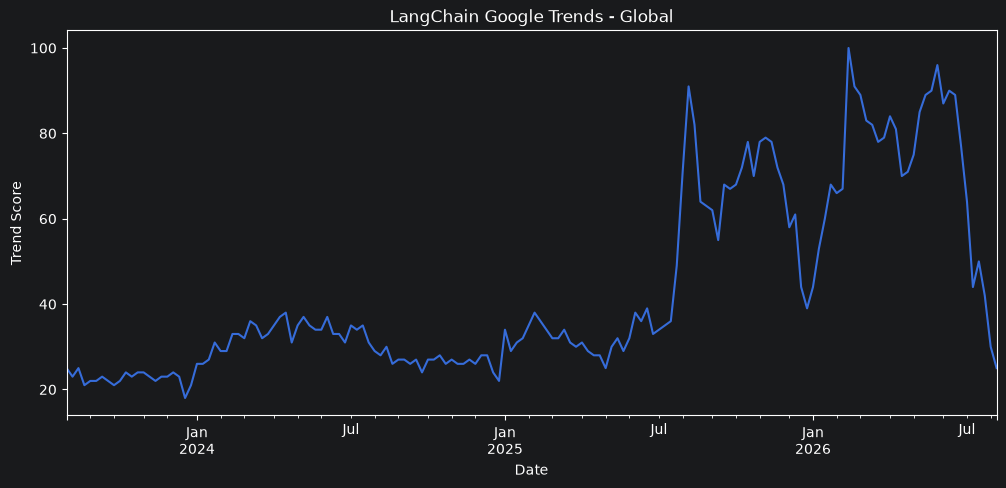

In [52]:
import matplotlib.pyplot as plt

### TrendScore sütununu tarihe göre çiziyoruz.
### Index'imiz date olduğu için x ekseni otomatik olarak tarih oluyor.

clean_df["trend_score"].plot(figsize=(12,5))

plt.title("LangChain Google Trends - Global")
plt.xlabel("Date")
plt.ylabel("Trend Score")
plt.show()

In [53]:
### Trend skorundaki kısa süreli dalgalamaları yumuşsatmak için 
### 4 haftalık hareketli ortalama(rolling mean) oluşturuyoruz
### window=4 ----> her satır için kendisi dahil son 4 haftasının ortalamasını hesaplar
### ilk üç değer Nan çıkabilir ama eksik veri problemi değil.


clean_df["rolling_4"] = (
    clean_df["trend_score"]
    .rolling(window=4)
    .mean()
)

In [54]:
### window 4 veya 8 olma etkisi 

In [55]:
clean_df.head(10)

,trend_score,isPartial,rolling_4
date,,,
2023-08-06,25,False,NaN
2023-08-13,23,False,NaN
2023-08-20,25,False,NaN
2023-08-27,21,False,23.50
2023-09-03,22,False,22.75
2023-09-10,22,False,22.50
2023-09-17,23,False,22.00
2023-09-24,22,False,22.25
2023-10-01,21,False,22.00


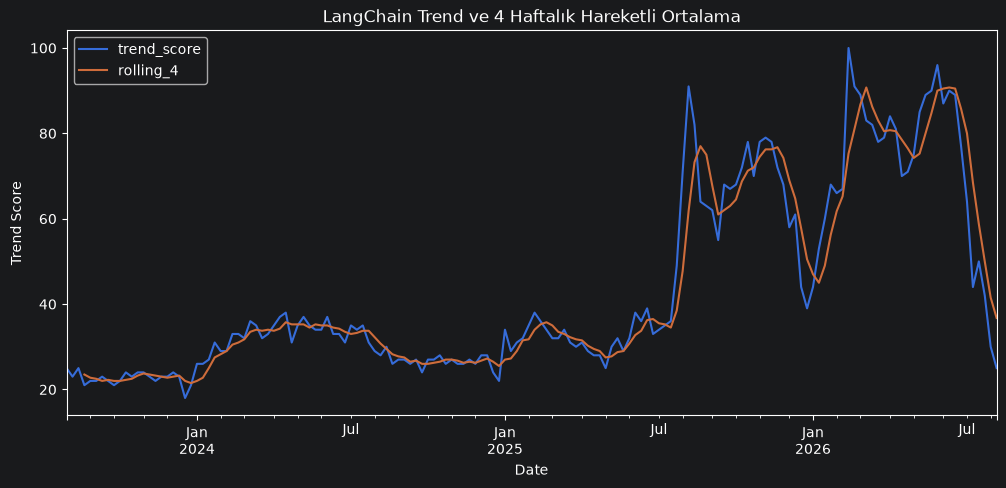

In [56]:
### Gerçek tend skoru ile 4 haftalık hareketli ortalamayı
### aynı grafik üzerinde karşılaştırıyoruz.
##
### trend_score -> gerçek ve daha dalgalı seri
### rolling_4   -> kısa dönem dalgalanmaları yumuşatılmış seri

clean_df[
    ["trend_score", "rolling_4"]
].plot(figsize=(12, 5))

plt.title("LangChain Trend ve 4 Haftalık Hareketli Ortalama")
plt.xlabel("Date")
plt.ylabel("Trend Score")
plt.show()

In [57]:
### LangChain'e olan ilginin en yüksek olduğu 10 hafta:

clean_df["trend_score"].nlargest(10)

date
2026-02-15    100
2026-05-31     96
2025-08-10     91
2026-02-22     91
2026-05-24     90
2026-06-14     90
2026-03-01     89
2026-05-17     89
2026-06-21     89
2026-06-07     87
Name: trend_score, dtype: int64

In [58]:
###LangChain'e olan ilginin en düşük olduğu 10 hafta:

clean_df["trend_score"].nsmallest(10)

date
2023-12-24    18
2023-08-27    21
2023-10-01    21
2023-12-31    21
2023-09-03    22
2023-09-10    22
2023-09-24    22
2023-10-08    22
2023-11-19    22
2024-12-29    22
Name: trend_score, dtype: int64

## Decomposition ----> Zaman serisi verisini analiz ederek trend (genel eğilim) ve sezonsallık (seasonality - örn: hafta sonu düşüşleri) bileşenlerine ayırmak

#### ayırmak için statsmodels kütüphanesindeki seasonal_decompose fonksiyonunu kullanıyoruz.

In [59]:
from statsmodels.tsa.seasonal import seasonal_decompose

####  Additive	             /        Multiplicative
####  Etkiler toplanır	      /       Etkiler çarpılır
####  Dalgalanma yaklaşık sabit	  /   Dalgalanma seri büyüdükçe büyür
####  Trend + Seasonal + Residual / Trend × Seasonal × Residual

In [60]:
decomposition = seasonal_decompose(
    clean_df["trend_score"],
    model="additive", ### Zaman serisini Trend + Sezonsallık + Artık (Residual) şeklinde parçala.
    
    period=52  ### ---> veri frekansımız haftalık (W-SUN) ve yaklaşık 52 hafta = 1 yıl
               ### ---> böylece yıllık olarak tekrar eden bir yapı olup olmadığını inceliyoruz
)

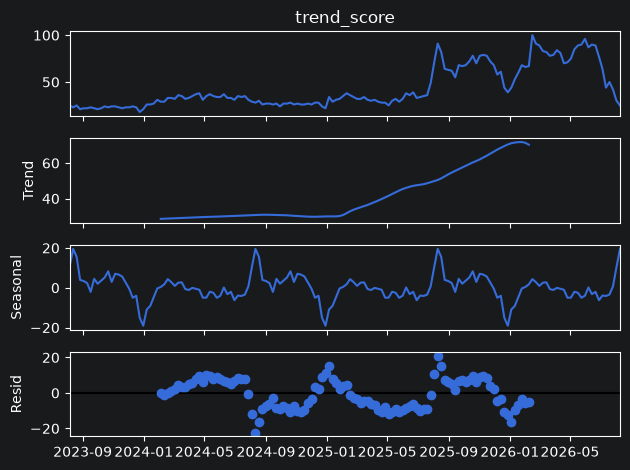

In [61]:
## Decomposition sonucunda oluşan dört bileşeni görselleştiriyoruz:
##
## Observed -> gerçek seri
## Trend    -> uzun dönemli yön
## Seasonal -> tekrar eden dönemsel yapı
## Resid    -> modelin açıklayamadığı kalan hareket

decomposition.plot()
plt.show()